In [ ]:
# 1. 간단한 그래프 생성 (LangGraph의 3요소)
# - 데이터를 담는 그릇인 상태(State), 작업을 수행하는 노드(Node), 흐름을 연결하는 **엣지(Edge)**의
# 기본 개념을 잡고 도식화하는 방법을 배웠습니다.

# 2. 단방향 그래프 기반 대화형 모델 (MemorySaver)
# - 단순히 한 번 묻고 답하는 것을 넘어, MemorySaver와 add_messages를 활용해 이전 대화 내역과
# 에이전트의 현재 뇌 상태를 지속해서 기억하는 체계를 구축했습니다.

# 3. 라우팅을 활용한 고객 클레임 에이전트 (규칙 기반 라우팅)
# - "환불", "취소" 같은 특정 키워드가 들어오면 LLM의 판단을 거치지 않고
# 강제로 '상담원 연결' 노드로 직행하게 만드는 안전장치를 코드로 구현했습니다.

# 4. 도구 활용 에이전트 (Agentic Routing)
# - 에이전트에게 4가지 무기(웹 검색, 노션 기록, 파일 저장, 슬랙 알림)를 쥐여주고(bind_tools),
# 스스로 상황에 맞는 무기를 꺼내 쓰도록 tools_condition과 ToolNode를 활용한 순환 루프를 만들었습니다.

# 5. 하이브리드 에이전트 (RAG + 웹 검색)
# - 사내 데이터(벡터 DB)를 검색하는 RAG 기능 자체를 하나의 도구로 만들어,
# 사용자의 질문이 사내 규정인지 외부 최신 뉴스인지 에이전트가 스스로 판단해 검색 방식을 고르도록 고도화했습니다.

# 6. 멀티 에이전트 시스템 구축 (협업 모델)
# - 정보를 수집하는 **'리서처(Researcher)'**와 이를 예쁘게 가공해서 배포하는 '퍼블리셔(Publisher)' 두 명의 에이전트를 만들고,
# 서로 바통을 터치하며 업무를 분업화하는 구조를 설계했습니다.

# 7. Human-in-the-Loop (HITL)
# - 슬랙 메시지 전송과 같은 외부 연동 작업을 수행하기 직전에 interrupt_before를 사용해
# 에이전트를 얼음(Pause) 상태로 만들고, 관리자의 승인(y/n)을 받아 안전하게 통제하는 법을 실습했습니다.

## LangGraph 활용하기
- AI가 어떤 순서로 일할지 결정하고, 필요하면 되돌아가기도 하는 **일 처리 흐름도(논리 구조)**
- LangGraph는 그래프 구조를 기반으로 복잡한 AI 고급 시스템, 다중 에이전트 등을 구현하는데 특화된 라이브러리
- 그래프에는 노드(node), 엣지(edge), 상태(state)가 있음
    - `노드`: 하나의 작업 혹은 단계
    - `엣지`: 노드의 연결 단위 (직선 혹은 화살표로 시각화됨)
    - `상태`: 노드가 작업한 결과를 기록해두는 곳 (모든 노드는 상태를 공유함)
- 여러 작업을 수행하는 에이전트가 각각의 작업에 대한 워크플로우를 정의된 그래프를 통해서 수행함
- 각 단계에서 상태를 직접 제어하고 수정할 수 있어 여러 에이전트의 상호작용을 효과적으로 모델링 할 수 있음
- (LangGraph는 **각 노드의 작업이 끝날 때마다 그 결과를 chunk 객체로 반환**하며, 개발자는 이를 받아 웹or앱으로 예쁘게 쏴주거나 중간에 에러가 났는지 코드로 검사할 수 있음. 또 LangSmith 사용 시에도 노드들의 순서부터 전달된 데이터까지 모든 작업이 다 표시됨)
- LangGraph로 자율형 에이전트를 구현하려면 스스로 판단하고 작업을 수정, 보완할 수 있도록 계속 사이클이 도는 **루프(Loop) 형태**로 만들어줘야 함

In [ ]:
!pip install -q langgraph

### **1. 간단한 그래프 생성하기**

In [1]:
# StateGraph: 상태 기반 그래프 생성 클래스
# START, END : 그래프 실행이 시작되는 시점과 종료되는 시점의 특수 노드
 # START- 사용자가 처음 입력한 데이터(초기 state)를 받아 어떤 노드에서 첫번째 작업을 시작할지 그래프에게 알려주는 역할
 # END- 에이전트의 모든 작업이 끝났음을 시스템에 알리고, 업데이트가 완료된 최종 상태를 사용자에게 반환. 전체 프로세스 종료하는 역할
from langgraph.graph import StateGraph, START, END

# typing: 데이터의 타입 정의 표준을 제공하는 모듈
# (사용할 데이터를 typing으로 지정해두면 전체 타입 뿐만 아니라 내용물까지 알 수 있고, 한번에 여러 타입 가능한 경우도 설정 가능.
# 최근 트렌드 AI라이브러리나 API에서는 대부분 타입 지정 방식을 표준으로 사용)

 # TypedDict: 딕셔너리의 key, value의 데이터 타입을 지정해주는 클래스
 # 정해진 key와 자료형 type만 허용함! 코드를 짤 때 오타나 잘못된 타입을 잡아줌
 # (langgraph에서 노드와 노드 사이에 데이터가 오갈 때 딕셔너리를 사용하는데, state의 데이터 구조를 정의할때 TypedDict를 상속받아 사용함)
from typing import TypedDict

# 그래프 도식화 클래스
from IPython.display import Image, display

In [2]:
# step 1: 상태(State) 정의
 # langgraph의 상태는 데이터 자체가 아니라 '데이터를 담을 그릇의 모양(설계도)'를 정의하는 곳
 # 1개의 에이전트에는 1개의 전역 상태(Global State)만 존재
class MyState(TypedDict) :
    messages: str

    # messages라는 변수에는 문자열만 들어갈 수 있고, 딕셔너리로 동작(TypedDict 상속)함
    # (실제 전달되는 데이터는 {'messages': '실제 들어간 문자열'} 형태가 됨)
    # 상태에 정의하지 않은 변수(key)로는 노드로 작업할 수 없음
    # (작업 자체는 가능하지만 이를 상태에 업데이트 할 수 없다고 보면 됨!!!)


# step 2. 노드(Node) 정의: AI가 특정 작업을 수행할 노드 만들기
 # 노드는 함수로 설정하며, 노드로 등록할 함수는 반드시 state를 첫 매개변수로 받아야 함
def say_hello(state: MyState):
    # MyState에 정의된 messages 확인
    print(f'(로그) 현재 상태(state): {state['messages']}')
    
    # 노드의 반환값은 state를 업데이트하는 목적이며, 딕셔너리로 반환
    return {"messages": "Hello, I'm LangGraph!"}


# step3. 그래프 구성 (흐름도 그리기)
graph = StateGraph(MyState)           # 우리가 정의한 state로 그래프 객체 생성
graph.add_node('hello', say_hello)    # AI 노드 추가 (say_hello 노드를 'hello'로 지칭함)

graph.add_edge(START, 'hello')     # 엣지 추가(시작 > hello)
graph.add_edge('hello', END)       # 엣지 추가(hello > 끝)


# step 4. 그래프 실행
app = graph.compile()            # 설계한 그래프를 실행 가능 객체로 변환
result = app.invoke({"messages": ""})  # 그래프 실행 (빈 메시지를 첫 노드에 전달)
                                       # (상태에 정의된 message를 활용해서 작업해야 함)

print(f"app 실행 결과 반환값: {result}")
print(f"최종 상태(state): {app.invoke({'messages':'안녕??'})}")

# 현재 노드가 할 수 있는 작업은 상태에 똑같은 인삿말을 업데이트 하는 것 뿐. 어떤 messages를 입력해도 같은 인사만 출력 중.
# 입력값을 활용하고 싶다면 노드 내에서 입력값을 읽어서 처리하는 로직을 짜야 함


(로그) 현재 상태(state): 
app 실행 결과 반환값: {'messages': "Hello, I'm LangGraph!"}
(로그) 현재 상태(state): 안녕??
최종 상태(state): {'messages': "Hello, I'm LangGraph!"}


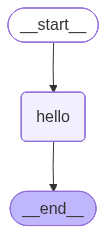

In [3]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

### **2. 단방향 그래프 기반 대화형 모델 만들기**
- **DAG(Directed Acyclic Graph)**: 한 방향으로 흐르는 노드와 엣지로 구성된 그래프 구조
- 단방향 작업이라면 Langchain의 LCEL처럼 chain으로 구성해도 되지만,
- 작업 중간에 실행을 멈추고 사람의 승인을 받거나 실행 전후의 상태(state)를 데이터베이스에 세이브 파일로 남기는 등 세부작업을 하고 싶다면 LangGraph 써야 함
- `MemorySaver`, `add_messages`

In [2]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# Annotated: 특정 변수의 자료형 및 사용 규칙에 대한 부가설명을 붙여주는 타입 클래스
from typing import Annotated

# add_messages: 메시지를 추가하여 누적해주는 클래스
 # 대화기록을 계속 저장하고 관리하기 위해서는 메시지를 누적으로 받아줘야 하는데 이때 활용
 # 또한 add_messages는 메시지의 고유ID를 검사해서 `이미 있는 메시지면 내용만 업데이트하고 새로운 메시지일 때만 뒤에 추가해줌`
 # 이전처럼 messages.append 할 필요 없음!!
from langgraph.graph.message import add_messages

# MemorySaver: LangGraph에서 활용하는 기억 메모리 저장소 클래스
 # Langchain의 memory 클래스는 이전 대화 내역을 다양한 방식으로 기억하지만, MemorySaver는 대화내역 뿐만 아니라
 # agent의 state를 통째로 저장하며 '지금 어떤 도구를 쓰는 중인지', '중간 계산값은 무엇인지' 까지 기억함
 # 추후 HITL를 구현할 때 일반 memory로는 구현할 수 없고 MemorySaver가 필수적임
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv()
MY_API_KEY = os.getenv('OPENAI_API_KEY')

In [ ]:
# llm 정의
llm = ChatOpenAI(
    api_key=MY_API_KEY,
    model='gpt-4o'
)

# 상태 정의
class ChatState(TypedDict) :
    # Annotated는 데이터의 형태를 규정하는 '타입 클래스'로 문법적으로 []를 사용함
     # add_messages는 메시지 추가 뿐만 아니라/ 같은 ID의 메시지가 들어오면 중복 추가하지 않고 덮어쓰는 등 똑똑한 처리까지 해줌
     # (우리는 채팅 모델 만들 거니까 메시지가 누적되어야 함. add_messages는 'role':'content' 형태로 메시지 관리함)
    messages: Annotated[list, add_messages]   # [데이터의 타입, 이전 상태와의 결합방식]


# 노드 정의
def chatbot_node(state: ChatState) :
    # 현재까지 누적된 메시지 리스트를 LLM에게 전달하여 답변 생성
     # state에 있는 딕셔너리에서 -> messages를 불러옴
    response = llm.invoke(state["messages"])

    # 생성된 답변을 messages에 반환 (add_messages에 의해 기존 리스트에 자동으로 누적됨)
    return {"messages":[response]}


# 그래프 객체 생성
graph2 = StateGraph(ChatState)

# 노드 및 엣지 추가
graph2.add_node('chatbot', chatbot_node)
graph2.add_edge(START, 'chatbot')
graph2.add_edge('chatbot', END)

# 메모리 객체 생성
memory = MemorySaver()

# 그래프 '실행 가능한 객체'로 변환 (메모리 추가)
# compile()을 하면 내부적으로 1. 연결성 확인(노드 잘 연결되어 있는지) 2. 데이터 규격 확인 3. 메모리 같은 기능 장착
app2 = graph2.compile(checkpointer=memory)

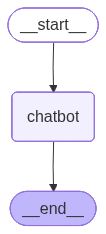

In [7]:
display(Image(app2.get_graph().draw_mermaid_png()))

In [ ]:
config = {'configurable': {'thread_id':'user_1'}}
# MemorySaver를 설정해도 config(설정값)가 없으면 누구의 대화인지 몰라서 기억 못함
# 사용자가 한 명이어도 설정해줘야 함!!

print('LangGraph를 활용한 챗봇 서비스에 오신 걸 환영합니다!')
print("대화를 종료하시려면 '종료'를 입력하세요")
print('='*50)

while True :
    user_input = input('사용자\t:')

    if user_input.strip() == '종료':
        print('대화를 종료합니다!')
        break

    # 빈칸 입력 방지 (엔터만 쳤을 경우 다시 입력받도록 함)
    # 빈칸이 입력되면 API 요청 요금이 낭비되고, 메모리에 쓸데없는 기록이 찰 수 있음
    if not user_input.strip() :
        continue

    print("AI\t: ", end="") # 답변 출력 시작점
    # end="" 이건 글자를 다 출력한 뒤에 줄바꿈하지 말고, 쭉 진행해 라는 뜻

    # stream 방식으로 답변 출력
    # (msg는 AIMessageChunk 형태, metadata는 딕셔너리 형태로 반환)
    for msg, metadata in app2.stream(
        {'messages': [('user', user_input)]},
        config,
        stream_mode='messages'   # 하나의 토큰 생성마다 즉시 반환
        # 'updates': 각 노드가 실행을 마치고 state를 업데이트할 때마다 상태값 반환
        # 'values': state 전체 내용을 통째로 계속 복사해서 반환
    ):
        # AIMessageChunk 청크 형태
         # AIMessageChunk(content='안', id='run-1234-5678')
         # AIMessageChunk(content='녕', id='run-1234-5678')
         
        # <meta data 주요 인자들>
         # langgraph_step: thread가 처음 생성된 이후 노드 경유 횟수
         # langgraph_node: 어떤 노드에서 작업 중인지 확인
         # ls_provider: LLM의 제공자로 멀티에이전트 구현시 코드는 claude에, 챗은 gpt에 요청하는 것처럼 LLM들에게 다른 작업을 시킬 수 있음
         # langgraph_triggers: 현재 노드가 실행되도록 한 주체 확인 (디버깅에 활용)


        # # 확인용 코드
        # print("msg", msg)
        # print()
        # print('metadata', metadata)
        # print()


        # msg에 내용이 들어있고 chatbot 노드에서 나온 메시지만 화면에 출력
        if msg.content and metadata.get('langgraph_node') == 'chatbot' :
            print(msg.content, end="", flush=True)

    print()

    print('<현재 상태 메모리에 저장된 내용 확인>')
    snapshot = app2.get_state(config)      # get_state: 현재상태를 가져옴 (StateSnapshot객체로 반환)
    print(snapshot.values)    # values: 현재 상태의 내용물 (messages에 HumanMessage, AIMessage가 있음)
    print()


LangGraph를 활용한 챗봇 서비스에 오신 걸 환영합니다!
대화를 종료하시려면 '종료'를 입력하세요
AI	: metadata {'thread_id': 'user_1', 'langgraph_step': 1, 'langgraph_node': 'chatbot', 'langgraph_triggers': ('branch:to:chatbot',), 'langgraph_path': ('__pregel_pull', 'chatbot'), 'langgraph_checkpoint_ns': 'chatbot:08d66bd2-b933-032c-d916-96094d8dfbe3', 'model': 'gpt-4o', 'model_name': 'gpt-4o', 'stream': False, '_type': 'openai-chat', 'checkpoint_ns': 'chatbot:08d66bd2-b933-032c-d916-96094d8dfbe3', 'ls_provider': 'openai', 'ls_model_name': 'gpt-4o', 'ls_model_type': 'chat', 'ls_temperature': None, 'ls_integration': 'langchain_chat_model'}
metadata {'thread_id': 'user_1', 'langgraph_step': 1, 'langgraph_node': 'chatbot', 'langgraph_triggers': ('branch:to:chatbot',), 'langgraph_path': ('__pregel_pull', 'chatbot'), 'langgraph_checkpoint_ns': 'chatbot:08d66bd2-b933-032c-d916-96094d8dfbe3', 'model': 'gpt-4o', 'model_name': 'gpt-4o', 'stream': False, '_type': 'openai-chat', 'checkpoint_ns': 'chatbot:08d66bd2-b933-032c-d916-96094d8

### **3. 라우팅을 활용한 고객 클레임 처리 에이전트 만들기**
- **Routing**: 노드 간의 정적이고 확정적인 실행 흐름
- **Custom Routing**: 특정 요구사항에 맞게 라우팅 로직을 직접 정의
- **Conditional Routing**: 노드 간의 동적인 이동경로를 결정하는 제어 분리 메커니즘. Rule-based Routing, Agentic Routing으로 나뉨
    - `Rule-based Routing`: 정해진 파이썬 코드 규칙대로만 다음 노드 선택
    - `Agentic Routing`: LLM이 다음 노드를 판단하고 선택에 반영하는 방식
        - 1. 특정 노드의 작업에서 LLM이 다음 상태(state)에 대한 자신의 판단결과를 상태에 기록해둠
        - 2. 현재 그래프의 상태 데이터를 인자로 받는 '라우팅 함수'를 호출
        - 3. 라우팅 함수가 상태 값을 확인하고 반환한 결과에 따라 다음으로 실행될 노드가 실시간으로 결정
        - 간단한 루프를 도는 에이전트라면 rule-based가 더 효율적, 복잡한 상황에서의 판단이 필요하면 Agentic이 좋음

#### `규칙 기반 라우팅 (Rule-based Routing)`

In [9]:
# 상태 정의
class ChatState(TypedDict) :
    messages: Annotated[list, add_messages]

# 노드 정의 ( 두명의 작업자 생성)
# 작업자 A : 일반적인 대답을 해주는 AI 노드
def chatbot_node(state: ChatState):
    print("[시스템] 일반 챗봇 노드가 실행되었습니당.")
    response = llm.invoke(state['messages'])
    return {'messages':[response]}      # "여기 내 작업 결과물! 이 중에서 messages라고 써진 칸에 이 데이터를 업데이트해줘!"
                                        # dict로 리턴하는 이유: 한 노드에서 여러개의 칸을 동시에 업데이트 할 수도 있기 때문에
                                        # list로 감싼 이유: add_messages는 리스트와 리스트를 더하는 방식으로 작동!!

# 작업자 B : 환불/취소 등 민감한 문제에는 상담원과 연결시키는 노드
def human_transfer_node(state: ChatState) :
    print('[시스템] 민감어 감지! 상담원 연결 노드가 실행되었습니당.')

    # 실제 상담원 연결 대신 고정메시지로 대체
    response = """불편을 드려 죄송합니다. 환불 및 취소 관련 문의는 정확한 처리를 위해 상담원에게 연결해드리겠습니다. (연결 중...)"""
    # role을 assistant로 직접 설정 (위 llm의 응답은 assistant가 자동으로 붙어서 출력됨)
    return {'messages':[('assistant', response)]}


# 조건부 라우팅 함수 (⭐ 조건부 엣지이기 때문에 함수 필요)
 # 해당 함수는 상태(state)를 확인한 뒤, 다음으로 이동할 노드의 이름(문자열)을 반환함
def route_to_next(state: ChatState) :
    # 가장 마지막에 들어온 메시지 확인
    last_message = state["messages"][-1]

    # 메시지의 텍스트만 추출
    user_text = last_message.content
    
    # 민감 단어가 포함되어 있는지 검사
    # (실무에서 쓰려면 정규표현식 패턴이나 좀 더 복잡한 로직을 넣어 여러 민감단어가 같이 나왔을때만 상담원 연결하는 게 좋음)
    if "환불" in user_text or "취소" in user_text:
        return "human_transfer_node"     # 함수 자체를 주는게 아니라, 노드의 이름을 알려주는 것뿐!!
    else :
        return "chatbot_node"
    

# 그래프 객체 생성
graph3 = StateGraph(ChatState)
graph3.add_node('chatbot_node', chatbot_node)
graph3.add_node('human_transfer_node', human_transfer_node)


# 조건부 라우팅 엣지 등록
graph3.add_conditional_edges(
    START,           # 시작 노드 (라우팅 함수 이전, 어떤 노드?)
    route_to_next,   # 조건부 라우팅 함수

    # 라우팅 함수를 통해 이동될 노드 ({'라우팅 함수가 반환할 문자열': '실제 연결 노드명'})
    {
        'chatbot_node': 'chatbot_node',
        'human_transfer_node':'human_transfer_node'
    }
)

# 엣지 등록
graph3.add_edge('chatbot_node', END)
graph3.add_edge('human_transfer_node', END)

memory = MemorySaver()
app3 = graph3.compile(checkpointer=memory)

config = {'configurable': {'thread_id':'customer_1'}}


print('안녕하세요 고객센터에 오신 것을 환영합니다.')
print('='*50)

while True:
    user_input = input('고객\t:')
    print(user_input)
    if user_input.strip()== '종료':
        print('대화를 종료합니다. 다음에 또 이용해주세요!')
        break
    if not user_input.strip():
        continue

    result = app3.invoke({'messages':[('user', user_input)]}, config)
    print(f"AI\t: {result['messages'][-1].content}")

안녕하세요 고객센터에 오신 것을 환영합니다.
안녕 결제 취소 하고 싶어
[시스템] 민감어 감지! 상담원 연결 노드가 실행되었습니당.
AI	: 불편을 드려 죄송합니다. 환불 및 취소 관련 문의는 정확한 처리를 위해 상담원에게 연결해드리겠습니다. (연결 중...)
종료
대화를 종료합니다. 다음에 또 이용해주세요!


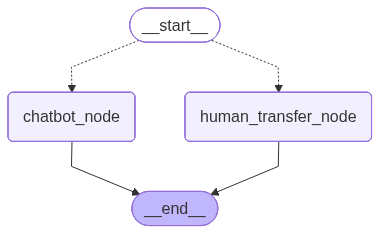

In [10]:
display(Image(app3.get_graph().draw_mermaid_png()))

# 조건부 라우팅 엣지는 점선으로 표시됨

### **4. 도구를 활용한 인터넷 검색 내용 정리 및 파일 전송 에이전트 제작**
#### `Agentic Routing`
- LLM 자체가 라우터가 되는 방식. 다음 단계로 어디를 갈지 LLM이 스스로 판단!
- **DCG(Directed Cyclic Graph)**: 순환하는 루프가 존재하는 그래프
> 에이전트에게 4가지 tool(웹 검색, 노션 기록, 파일 저장, 슬랙 알림)를 쥐여주고(bind_tools),
>
> 스스로 상황에 맞는 tool을 꺼내 쓰도록 tools_condition과 ToolNode를 활용한 순환 루프를 만듦

- **타빌리 검색**
    - 타빌리 사이트: https://www.tavily.com/
    - `TAVILY_API_KEY` 가입 시 할당
- **노션 API**
    - 노션 사이트: https://www.notion.com/ko
    - 노션 개발자 API 사이트: https://www.notion.so/profile/integrations/public
    - `NOTION_API_KEY` API 통합 편집 페이지의 '프라이빗 API 통합 시크릿'
    - `NOTION_DATABASE_ID` DB표가 있는 노션 페이지의 url의 워크스페이스 이름 뒤 '/' 부터 '?'전까지 32글자
- **슬랙 API**
    - 슬랙 앱(또는 웹페이지)에서 에이전트 실습용 워크스페이스 추가
    - 슬랙 API 사이트: https://api.slack.com/apps
    - `SLACK_BOT_TOKEN` 슬랙 앱의 'Bot User OAuth Token'
    - `SLACK_CHANNEL_ID` 메시지를 보낼 채널 ID (실습용 채널의 우상단 ... 눌러서 채널 세부정보 열기의 맨하단에 있음)

In [ ]:
!pip install tavily-python langchain-tavily slack-sdk

In [4]:
import os
import json
import requests as req
from dotenv import load_dotenv
# List : 리스트 타입을 알려주는 클래스
from typing import Annotated, TypedDict, List

# WebClient : 슬랙 API 통신 클래스
from slack_sdk import WebClient
# SlackApiError : 슬랙 전용 에러 처리기 클래스
from slack_sdk.errors import SlackApiError

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage

# 랭체인 지원 타빌리 검색 클래스
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

# ToolNode : LLM이 도구를 결정하면 파이썬에서 해당 도구를 실행해주는 자동 실행기
# tools_condition : 랭그래프 제공 조건부 라우팅 클래스
from langgraph.prebuilt import ToolNode, tools_condition

In [9]:
# 환경변수 로드
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
NOTION_API_KEY = os.getenv("NOTION_API_KEY")
NOTION_DATABASE_ID = os.getenv("NOTION_DATABASE_ID")
SLACK_BOT_TOKEN = os.getenv("SLACK_BOT_TOKEN")
SLACK_CHANNEL_ID = os.getenv("SLACK_CHANNEL_ID")

if not all ([OPENAI_API_KEY, TAVILY_API_KEY, NOTION_API_KEY, NOTION_DATABASE_ID, 
             SLACK_BOT_TOKEN, SLACK_CHANNEL_ID]):
    print('경고: .env 파일에 필요한 API KEY가 모두 설정되지 않았습니당')


# ================= <도구 정의> ===================

# 1. 인터넷 검색 도구 (Tavily)
 # langchain과 연동된 Tavily 클래스이므로 에이전트가 바로 활용 가능한 형태
# max_result: 반환 받을 최대 검색 결과 수
search_tool = TavilySearchResults(max_result=3)

# 2. Notion API 연동 도구
@tool
def create_notion_page(title:str, content:str) -> str:
    """검색된 정보를 바탕으로 Notion 데이터베이스에 새로운 페이지를 생성합니다.
    
    Args:
        title: 새 페이지의 제목 (검색 주제)
        content: 페이지 본문에 들어갈 내용 (검색 결과 요약)
    """
    
    # 노션 api url은 고정
    url = "https://api.notion.com/v1/pages"

    headers = {
        # 사용자 인증
        "Authorization": f"Bearer {NOTION_API_KEY}",
        # 노션 API 서버에서 정해둔 데이터 형식은 JSON
        "Content-Type": "application/json",
        # 개편이 있기 전에는 모두 2022년도 규칙서를 기준으로 통신한다는 뜻
        "Notion-Version": "2022-06-28"
    }

    # Notion API 요구사항에 맞게 JSON으로 데이터 구성
    # (노션은 빈 페이지에 블록들을 하나씩 조립해서 문서 만드는 구조라 이런 JSON형식의 지침과 연동이 좋음)
     # 노션 개발자 공식 문서: https://developers.notion.com/reference/post-page
    data = {
        # parent: 📌 위치 지정. 노션의 어느 표(데이터베이스)에 넣을지 설정
        "parent": {"database_id": NOTION_DATABASE_ID},
        # properties: 📌 데이터베이스 속성. 표의 어느 칸에 넣을지 설정
        "properties": {
            "제목": {
                "title": [
                    {
                        "text": {
                            "content": title   # 제목(함수의 매개변수)
                        }
                    }
                ]
            }
        },
        # children: 📌 본문 내용. 페이지 안에 어떤 본문 내용을 넣을지 설정
        #           (여러개의 문단을 한 번에 넣기 위해 []로 구성)
        "children": [
            {
                # 공식 문서 참조: https://developers.notion.com/reference/block
                "object": "block",
                "type": "paragraph",   # 일반 텍스트 단락(heading_1 이면 큰 제목)
                # 단락 세부 설정
                "paragraph": {
                    # 글자 꾸미기 공간(굵게, 기울어짐, 하이퍼링크 등)
                    "rich_text": [
                        {
                            "type": "text",
                            "text": {
                                # 노션 표 하나의 셀에 2000자까지만 넣을 수 있음
                                "content": content[:1999]
                            }
                        }
                    ]
                }
            }
        ]
    }
    try :
        res = req.post(url, headers=headers, json=data)

        # HTTP 응답이 성공(200번대)이 아닐 경우 노션 서버의 에러메시지를 직접 반환
        if not res.ok :
            return f"Notion API 에러 발생! 상태코드: {res.status_code}, 상세내용: {res.text}"
        # 상태코드(status_code)를 보고 에러를 발생시키도록 설정
        # (발생하는 에러를 직접 알 수 있도록. 설정이 없으면 연결된 다른 곳에서 발생한 에러가 출력될 수 있어 디버깅 힘듦)

        res.raise_for_status()
        return f"Notion 페이지 '{title}' 생성이 완료되었습니다."
    
    except Exception as e:
        return f"Notion 페이지 생성 실패 (파이썬 에러): {e}"
    

# 3. 파일 저장 도구
@tool
def save_to_file(filename:str, content:str) -> str:
    """주어진 내용을 로컬에 TXT 파일로 저장합니다.
    
    Args:
        filename: 저장할 파일 이름(예: report.txt)
        content: 파일에 기록할 내용
    """
    try :
        with open(filename, "w", encoding='utf-8') as f :
            f.write(content)
        return f"파일 '{filename}'이 성공적으로 저장되었습니다."
    
    except Exception as e :
        return f"파일 저장 실패: {e}"
    

# 4. 슬랙 메시지 전송 도구
@tool
def send_slack_message(message: str) -> str :
    """작업 완료 알림 및 요약 메시지를 Slack 채널로 전송합니다.
    
    Args:
        message: Slack으로 보낼 메시지 내용
    """

    # 슬랙 전용 통신 객체 생성 (슬랙 본사에서 API 연결을 편하게 하기 위해 제공)
    # (WebClient가 없었다면 노션처럼 request 모듈을 사용해야 함)
    client = WebClient(token=SLACK_BOT_TOKEN)

    try:
        # chat_postMessage : Slack 채널에 메시지 게시
        response = client.chat_postMessage(
            channel=SLACK_CHANNEL_ID,   # 슬랙 채널 ID
            text=message
        )
        return f"Slack 메시지가 성공적으로 전송되었습니다."
    
    except Exception as e :
        return f"Slack 메시지 전송 실패: {e}"
    


# 에이전트가 사용할 도구 목록
tools = [search_tool, create_notion_page, save_to_file, send_slack_message]

# LLM 로드
llm = ChatOpenAI(model='gpt-4o', temperature=0.1)

# bind_tools : LLM에게 우리가 정의한 도구의 존재와 사용법을 인지시킴
#(LangGraph의 도구 연결 표준으로 반드시 사용해야 함)
# 1) 도구들의 이름, 독스트링, 입력 매개변수 등을 읽어옴
# 2) 각 회사 서버가 알아들을 수 있는 JSON 형태의 '도구사용설명서'로 변환
# 3) 도구를 쓸 수 있는 특수 LLM 객체로 반환
llm_with_tools = llm.bind_tools(tools)


# ================= <LangGraph 만들기> ===================

# 상태 정의
class AgentState(TypedDict) :
    messages: Annotated[list, add_messages]

# 노드 정의
# 1. 에이전트 노드 (Agent Node)
 # 사용자의 요청을 분석하고, 응답을 생성하거나 도구 사용 여부를 판단
def agent_node(state: AgentState) :
    print('\n[시스템] 에이전트가 동작 중입니다...')
    messages = state['messages']

    # 모델에게 부여할 시스템 프롬프트
    # (이 프롬프트를 어떻게 작성하냐에 따라 LLM이 도구를 선택하는 성능에 결정적 영향을 미침)
    system_message = SystemMessage(
        content = f"""당신은 정보 검색, 노션 기록, 문서 저장, 슬랙 알림 발송을 자동화하는 유능한 AI 어시스턴트입니다.
        사용자의 요청에 따라 다음 단계를 순차적으로 수행하세요:
        1. {search_tool.name} 도구를 사용하여 관련 정보를 검색하세요.
        2. 검색된 정보를 요약하여 {create_notion_page.name} 도구로 Notion에 저장하세요.
        3. 동일한 요약 내용을 {save_to_file.name} 도구로 '.txt' 파일로 로컬에 저장하세요.
        4. 모든 작업이 완료되면 {send_slack_message.name} 도구를 사용해 슬랙으로 완료 알림 및 간단한 요약을 전송하세요.
        
        모든 도구 사용이 성공적으로 완료되었음을 확인 후 사용자에게 최종 답변을 제공하세요.
        """
    )

    # 상태에 저장된 대화내역 앞에 시스템 프롬프트를 추가하여 LLM에 요청
    response = llm_with_tools.invoke([system_message] + messages)

    return {'messages':[response]}  # LLM 응답 내역까지 반환 (상태에 업데이트)

# 2. 도구 노드 (Tool Node)
 # ToolNode 사용하면 별도의 def 구현없이 LLM이 도구 호출을 요청했을때 함수를 실행하고 결과를 반환하는 노드를 자동생성함
tool_node = ToolNode(tools)


graph = StateGraph(AgentState)
graph.add_node('agent', agent_node)
graph.add_node('tools', tool_node)        # 도구 노드

graph.add_edge(START, 'agent')
graph.add_conditional_edges(              # 조건부 라우팅 엣지
    'agent',
    tools_condition
    # tools_condition: 에이전트의 마지막 메시지를 확인하여 도구 호출 정보에 따라 tools 노드 혹은 END 노드로 갈지 결정하는 객체
    # 얘 덕분에 조건부 라우팅 엣지 함수를 따로 쓰지 않아도 됨!! 다 수행했으면 END노드로 보내서 에이전트 종료시킴!!

    # (내부 로직은 예적 코드처럼 tool_calls를 확인하고 있으면 tools로, 없으면 END로 가는 조건문 코드
    # tools_condition 사용할 때는 도구 노드 명칭이 반드시 'tools'여야 함)
)

# 도구 사용이 완료되면 결과값을 다시 에이전트 노드로 넘길 수 있게 설계
# 에이전트 노드는 도구 실행 결과를 확인하고 다음 행동을 결정하는 루프 구조 완성
graph.add_edge('tools', 'agent')


memory = MemorySaver()
agent_app = graph.compile(checkpointer=memory)


# =================== 에이전트 실행 함수 ==============================
def run_agent() :
    config = {'configurable': {'thread_id':'customer_1'}}


    print('안녕하세요 자율 에이전트 시스템에 오신 것을 환영합니다.')
    print("대화를 종료하려면 '종료'를 입력하세요")
    print('='*50)

    while True:
        user_input = input('사용자\t:')
        print(user_input)

        if user_input.strip()== '종료':
            print('대화를 종료합니다. 다음에 또 이용해주세요!')
            break
        if not user_input.strip():
            continue

        print("\n --- 에이전트 처리 과정 ---")
        for event in agent_app.stream(
            {"messages": [("user", user_input)]},
            config, stream_mode="updates"
        ):
            # stream_mode를 updates로 설정하면 'event' 변수는 상태를 업데이트 할 메시지 딕셔너리 형태로 반환됨
            # key(node_name)는 방금 실행을 마친 노드 이름 ex) 'agent' or 'tools'
            # value(state_update)는 노드의 실행결과로 상태에 업데이트 할 메시지 딕셔너리
            for node_name, state_update in event.items() :

                # 에이전트 노드라면
                if node_name == 'agent' :
                    # 노드 실행 결과 중 가장 최신(마지막) 메시지
                    message = state_update["messages"][-1]
                    
                    if message.tool_calls :                           # 메시지에 도구 호출이 있다면
                        print(f"\n[에이전트 판단] 다음 도구를 호출합니다.")
                        for tool_call in message.tool_calls :
                            print(f" - 도구 이름: {tool_call["name"]}, 인자: {tool_call["args"]}")
                
                    else :                                            # 도구 호출이 없는 경우
                        print(f"\n에이전트 답변: {message.content}")

                # 도구 노드라면
                elif node_name == 'tools' :
                    messages = state_update["messages"]
                    for msg in messages :
                        # 내용이 길 수 있으니 200자까지만 출력
                        print(f"[도구 실행결과 ({msg.name})]: {msg.content[:200]}...")
                    
        print("\n ===========================================")

C:\Users\agnes\AppData\Local\Temp\ipykernel_6468\3609160867.py:20: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_result=3)


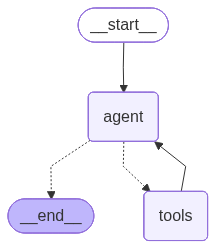

In [14]:
display(Image(agent_app.get_graph().draw_mermaid_png()))

In [20]:
run_agent()

안녕하세요 자율 에이전트 시스템에 오신 것을 환영합니다.
대화를 종료하려면 '종료'를 입력하세요
2026년 3월 키워드를 조사해서 노션에 요약 정리해주고, txt파일로도 저장해줘. 그리고 슬랙에 결과를 보고해줘.

 --- 에이전트 처리 과정 ---

[시스템] 에이전트가 동작 중입니다...

[에이전트 판단] 다음 도구를 호출합니다.
 - 도구 이름: tavily_search_results_json, 인자: {'query': '2026년 3월 트렌드 키워드'}
[도구 실행결과 (tavily_search_results_json)]: [{"title": "2026년 3월 It Ai 트렌드 키워드 화제", "url": "https://www.instagram.com/popular/2026%EB%85%84-3%EC%9B%94-it-ai-%ED%8A%B8%EB%A0%8C%EB%93%9C-%ED%82%A4%EC%9B%8C%EB%93%9C-%ED%99%94%EC%A0%9C", "content":...

[시스템] 에이전트가 동작 중입니다...

[에이전트 판단] 다음 도구를 호출합니다.
 - 도구 이름: create_notion_page, 인자: {'title': '2026년 3월 트렌드 키워드', 'content': "2026년 3월의 주요 트렌드 키워드는 다음과 같습니다:\n\n1. **봄맞이 및 신학기**: 봄 시즌과 신학기가 시작되면서 관련 소비가 집중됩니다. '봄맞이', '신학기 준비', '개강 할인' 같은 키워드가 주목받고 있습니다.\n2. **제로클릭 (Zero-Click)**: 검색 결과 페이지에서 클릭 없이 정보를 얻는 트렌드가 강화되고 있습니다.\n3. **화이트데이 및 관계 마케팅**: 화이트데이를 맞아 관계와 감정을 중시하는 마케팅이 활발합니다.\n4. **봄 시즌 시작 및 환절기 건강 관리**: 봄 시즌의 시작과 함께 환절기 건강 관리에 대한 관심이 증가하고 있습니다.\n\n이러한 트렌드는 소비자 경험 중심의 접근과 계절적 변화에 따른 소비 패턴을

### **5. RAG와 웹 검색을 스스로 판단하여 선택하는 하이브리드 에이전트**
- 이전에 배운 RAG(검색 증강 생성) 구조를 하나의 도구(Tool)로 만들어서 에이전트에 쥐어주기
- 사내 규정은 RAG 도구를 쓰고, 최신 트렌드는 웹 검색 도구를 쓰도록 구현

In [22]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

In [23]:
# 만들어둔 벡터 DB내용 불러오기
my_embedding = OpenAIEmbeddings(
    model='text-embedding-3-small',
    api_key=MY_API_KEY
)

my_directory = "/VectorStores"

vectordb = Chroma(
    persist_directory=my_directory,
    embedding_function=my_embedding
)

my_retriever = vectordb.as_retriever(search_kwargs={'k':3})

In [24]:
# 기존 청크 개수 확인
vectordb._collection.count()

28

In [ ]:
# 1. 인터넷 검색 도구 (Tavily)
 # langchain과 연동된 Tavily 클래스이므로 에이전트가 바로 활용 가능한 형태
search_tool = TavilySearchResults(max_results=3)

# RAG 구조로 검색을 수행하는 도구 (도구 설명을 잘 써주는 게 중요!!)
@tool
def search_internal_docs(query: str) -> str:
    """기술보증기금의 주요업무인 기술평가 및 기술보증에 대한 질문일 때 이 도구를 사용하여 검색합니다.
    
    Args:
        query: 사내 규정집에서 검색할 질문 (예: '기술평가 업무가 무엇이지?')
    """
    try:
        docs = my_retriever.invoke(query)
        # 검색된 문서들의 본문 내용을 하나의 문자열로 반환
        return '\n\n'.join([doc.page_content for doc in docs])
 
    except Exception as e :
        return f"사내 문서 검색 중 오류가 발생했습니다: {e}"


# 두가지 도구 (타빌리 검색, 사내문서 검색)
tools = [search_tool, search_internal_docs]

# LLM 로드 및 도구 바인딩
llm = ChatOpenAI(model='gpt-4o', temperature=0.1)
llm_with_tools = llm.bind_tools(tools)


# 상태 정의, 노드 정의
class HybridAgentState(TypedDict) :
    messages: Annotated[list, add_messages]

def hybrid_agnet_node(state: HybridAgentState) :
    messages = state['messages']

    system_message = SystemMessage(
        content = f"""당신은 사용자의 질문에 가장 정확한 답을 제공하는 스마트 비서입니다.
        질문의 성격을 파악하여 도구 사용 여부를 스스로 판단하세요.

        1. 기술보증기금의 주요 업무 관련 질문(기술평가, 기술보증): {search_internal_docs.name} 모두 사용
        2. 최신 뉴스, 실시간 정보 또는 당신이 모르는 외부 정보: {search_tool.name} 도구 사용.
        3. 단순한 인사말이나 이미 알고 있는 일반적이고 상식적인 질문: 검색 도구 사용하지 말고 즉시 당신의 지식으로 답변하세요.

        친절하고 명확한 톤으로 답변해주세요.
        """
    )

    response = llm_with_tools.invoke([system_message] + messages)
    return {'messages':[response]}

# 그래프 만들기
graph = StateGraph(HybridAgentState)

graph.add_node('agent', hybrid_agnet_node)
graph.add_node('tools', ToolNode(tools))

graph.add_edge(START, 'agent')  
graph.add_conditional_edges('agent', tools_condition)
graph.add_edge('tools', 'agent')

memory = MemorySaver()
hybrid_app = graph.compile(checkpointer=memory)    


# 실행하는 함수
def run_hybrid_agent() :
    config = {'configurable': {'thread_id':'customer_1'}}


    print('안녕하세요 RAG 활용 에이전트 시스템에 오신 것을 환영합니다.')
    print("대화를 종료하려면 '종료'를 입력하세요")
    print('='*50)

    while True:
        user_input = input('사용자\t:')
        print(user_input)

        if user_input.strip()== '종료':
            print('대화를 종료합니다. 다음에 또 이용해주세요!')
            break
        if not user_input.strip():
            continue

        print("\n --- 에이전트 처리 과정 ---")

        for event in hybrid_app.stream(
            {"messages": [("user", user_input)]},
            config, stream_mode="updates"
        ):

            for node_name, state_update in event.items() :

                if node_name == 'agent' :
                    message = state_update["messages"][-1]
                    
                    if message.tool_calls :                           # 메시지에 도구 호출이 있다면
                        print(f"\n[에이전트 판단] 다음 도구를 호출합니다.")
                        for tool_call in message.tool_calls :
                            selected_tool = tool_call['name']

                            # RAG인 경우
                            if selected_tool == "search_internal_docs" :
                                print(f"[판단] 사내문서 관련 질문입니다 -> RAG 도구({selected_tool}) 작동!")

                            # 웹 검색인 경우
                            else:
                                print(f"[판단] 외부 질문입니다 -> 웹 검색도구 ({selected_tool}) 작동!")
                
                
                    else :                                            # 도구 호출이 없는 경우
                        print(f"\n에이전트 답변: {message.content}")

                # 도구 노드라면
                elif node_name == 'tools' :
                    messages = state_update["messages"]
                    for msg in messages :
                        # 내용이 길 수 있으니 200자까지만 출력
                        print(f"[도구 실행결과 ({msg.name})]: {msg.content[:200]}...")
                    
        print("\n ===========================================")

In [35]:
run_hybrid_agent()

안녕하세요 RAG 활용 에이전트 시스템에 오신 것을 환영합니다.
대화를 종료하려면 '종료'를 입력하세요
안녕

 --- 에이전트 처리 과정 ---

에이전트 답변: 안녕하세요! 어떻게 도와드릴까요?

기술평가에 대해서 알려줘

 --- 에이전트 처리 과정 ---

[에이전트 판단] 다음 도구를 호출합니다.
[판단] 사내문서 관련 질문입니다 -> RAG 도구(search_internal_docs) 작동!
[도구 실행결과 (search_internal_docs)]: 페이지 2 / 6 
 
 (2) 기술평가3 
기술평가란?- 대상기술의 기술성, 시장성, 사업타당성 등을 분석하고 결과를 금액, 등급, 의견 등으로 
표현하는 것이다.  
✓ 기술평가는 기술수준 등 기술자체에 대한 평가를 표현한 용어지만, 기술과 기업(사업)간의 밀접한 관련
성으로 인해서 최근에는 위의 의미로 사용됨 
✓ 기술가치평가는 기술평가+가치평가가 결...

에이전트 답변: 기술평가는 대상 기술의 기술성, 시장성, 사업타당성 등을 분석하여 그 결과를 금액, 등급, 의견 등으로 표현하는 과정입니다. 기술평가는 기술 자체에 대한 평가뿐만 아니라, 기술과 기업(사업) 간의 밀접한 관련성으로 인해 기술가치평가라는 용어로도 사용됩니다. 이는 기술적인 요소를 기반으로 시장에서의 가치를 평가하는 것을 의미합니다.

기술평가의 유형은 크게 세 가지로 나뉩니다:

1. **기술가치평가**: 기술의 가치를 금액으로 표시하여 평가하는 것으로, 벤처기업의 현물출자, 기술의 담보가치 산정, 기술이전 및 거래 기준가격 산정 등을 포함합니다.

2. **기술사업 타당성평가**: 특정 기술이나 아이디어의 사업화 가능성을 평가하는 것으로, 벤처기업 확인, 정책자금 지원 대상자 선정, 금융기관의 여신심사용 평가 등을 포함합니다.

3. **종합기술평가**: 기업이 보유한 기술을 경영환경 및 사업전망과 함께 종합적으로 평가하는 것으로, 투자용 평가, 코스닥시장 상장 평가 등을 포함합니다.

기술평가는 기술성, 시장성, 사업성을 종

### **6. 멀티 에이전트 시스템 구축**
- 하나의 에이전트에 여러 도구를 주고 시키면 되지, 굳이 여러 에이전트를 만들 필요가 있을까?
- **멀티 에이전트 사용 이유**
 1) `AI 뇌 용량 (Context Window)과 판단력의 한계`
    - 사용자의 질문이 들어왔을 때 서버(도구)가 20개가 있다면 이 중에 무엇을 사용할지 심각한 인지 과부하게 걸릴 수 있음
 2) `페르소나의 모순`
    - 에이전트가 완벽하게 일하려면 system prompt로 뼈대를 강력하게 잡아줘야 하는데 이때 페르소나가 충돌할 수 있음
 3) `상호 검증 구현`
    - 자기가 쓴 글의 오타나 짠 코드의 버그를 잘 찾지 못하듯, AI도 같아서 이를 작성자와 검수자로 나누어 지속적인 고도화 가능

AI 자동화 리서치 & 배포
- 1. **리서처(Researcher)** : 냉철한 이성을 가졌으며, 웹 검색과 사내 RAG검색 도구만 사용할 수 있음. 정보 수집 후 배포 담당자에게 넘김.
- 2. **퍼블리셔(Publisher)** : 창의적인 글솜씨를 가졌으며 노션 저장, 파일 저장, 슬랙 전송 도구만 사용할 수 있음. 리서쳐의 자료를 받아 예쁘게 포장하고 배포함.
- 두 에이전트가 **각각의 전용 도구와 전용 LLM**을 가지며, 일이 끝나면 다음 담당자에게 바톤을 넘기는 커스텀 라우팅을 적용해보자

In [45]:
# 상태 정의
class EnterpriseTeamState(TypedDict) :
    messages: Annotated[list, add_messages]

# 에이전트 역할별 전용 도구함 분리
researcher_tools = [search_tool, search_internal_docs]
publisher_tools = [create_notion_page, save_to_file, send_slack_message]

# 역할별 LLM 설정 및 도구 바인딩
 # 리서처는 팩트 기반이므로 temp 낮게
researcher_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.2).bind_tools(researcher_tools)
 # 퍼블리셔는 글을 예쁘게 써야 하므로 temp 높게 설정
publisher_llm = ChatOpenAI(model='gpt-4o', temperature=0.7).bind_tools(publisher_tools)

# 리서처 노드 (정보 수집 전담)
def researcher_node(state: EnterpriseTeamState) :
    messages = state["messages"]

    system_message = SystemMessage(
        content = f"""당신은 정보 수집 전문 리서처(Researcher)입니다.
        사용자의 요청을 분석하여 다음 도구를 활용해 팩트 기반의 정보를 수집하세요.

        - 기술보증기금 주요업무(기술평가/보증): {search_internal_docs.name}
        - 외부 정보: {search_tool.name}

        수집된 정보를 마쳤다면 다음 담당자인 '퍼블리셔'가 문서를 작성하기 편하도록 수집된 정보를 마크다운 형식으로
        깔끔하게 요약해서 답변으로 남겨주세요. 당신은 문서를 외부로 발송하거나 저장하는 도구를 쓸 수 없으니 오직 요약만 하세요.
        """
    )

    response = researcher_llm.invoke([system_message] + messages)
    return {'messages': [response]}

# 퍼블리셔 노드 (문서화 및 배포 전담)
def publisher_node(state: EnterpriseTeamState) :
    messages = state["messages"]

    system_message = SystemMessage(
        content = f"""당신은 문서 배포 전문 리서처(Publisher)입니다.
        대화 기록을 읽고, 리서처(Researcher)가 요약해둔 자료가 있다면 즉시 다음 순서대로 작업을 수행하세요.

        1. 요약본을 바탕으로 노션 페이지를 생성하세요. ({create_notion_page.name})
        2. 동일한 내용을 로컬 txt파일로 저장하세요. ({save_to_file.name})
        3. 모든 작업이 완료되면 슬랙으로 완료 보고를 하세요. ({send_slack_message.name})
        
        모든 도구 사용이 성공적으로 끝나면, 사용자에게 "요청하신 자료의 리서치부터 노션 저장, 슬랙 보고까지 완벽히 처리했습니다."
        라고 최종 안내문을 남기세요.
        """
    )

    response = publisher_llm.invoke([system_message] + messages)
    return {'messages': [response]}


# 기존의 tools_condition은 도구 사용이 완료되면 무조건 END로 빠지기 때문에 이번에는 직접 라우팅 함수 선언
# 조건부 라우팅 함수
def researher_router(state: EnterpriseTeamState) :
    message = state["messages"][-1]
    # 도구를 쓰겠다면 리서처 전용 도구 노드로 분기
    if message.tool_calls :
        return "researcher_tools"
    # 도구 사용이 끝나고 요약본을 만들었다면 다음으로 퍼블리셔에게...
    else :
        return "publisher"

def publisher_router(state: EnterpriseTeamState) :
    message = state["messages"][-1]
    # 도구를 쓰겠다면 퍼블리셔 전용 도구 노드로 분기
    if message.tool_calls :
        return "publisher_tools"
    # 배포 작업까지 다 끝났으면 작업 종료
    else :
        return END


graph = StateGraph(EnterpriseTeamState)

graph.add_node('researcher', researcher_node)                  # 리서처 노드
graph.add_node('researcher_tools', ToolNode(researcher_tools)) # 리서처의 도구 노드
graph.add_node('publisher', publisher_node)                    # 퍼블리셔 노드
graph.add_node('publisher_tools', ToolNode(publisher_tools))   # 퍼블리셔의 도구 노드


graph.add_edge(START, 'researcher')
graph.add_conditional_edges('researcher', researher_router,   # 조건부 라우팅 함수
                            # <그래프 이미지 출력시 필요>
                            {'researcher_tools': "researcher_tools",
                            "publisher":"publisher"})
# ⭐ 도구 사용한 결과를 다시 researcher에게 넘겨주기
graph.add_edge('researcher_tools', 'researcher') 

graph.add_conditional_edges('publisher', publisher_router,
                            {'publisher_tools': "publisher_tools",
                            END:END})
graph.add_edge('publisher_tools', 'publisher') 


memory = MemorySaver()
enterprise_app = graph.compile(checkpointer=memory)



# ============== 실행 함수 ==================
def run_enterprise_team() :
    config = {'configurable': {'thread_id':'customer_1'}}

    print('[멀티 에이전트 자동화 시스템 가동]')
    print("대화를 종료하려면 '종료'를 입력하세요")
    print('='*50)

    while True:
        user_input = input('사용자\t:')
        print(user_input)

        if user_input.strip()== '종료':
            print('대화를 종료합니다. 다음에 또 이용해주세요!')
            break
        if not user_input.strip():
            continue

        print("\n --- 멀티 에이전트 팀 작업 현황 ---")

        for event in enterprise_app.stream(
            {"messages": [("user", user_input)]},
            config, stream_mode="updates"
        ):
            
            for node_name, state_update in event.items() :
                # 리서처 노드라면
                if node_name == "researcher" :
                    msg = state_update["messages"][-1]
                    if msg.tool_calls :
                        for tool in msg.tool_calls :
                            print(f"[리서치] 자료 수집 중 -> 도구({tool['name']}) 가동")
                    else :
                        print(f"[리서처] 자료 수집 완! -> [퍼블리셔 부서로 이관]")

                # 리서처 도구 노드라면
                elif node_name == "researcher_tools" :
                    for msg in state_update["messages"] :
                        preview = msg.content[:40].replace("\n", " ")
                        print(f" (리서처 도구) 데이터 확보! [{preview}...]")

                # 퍼블리셔 노드라면
                elif node_name == "publisher" :
                    msg = state_update["messages"][-1]
                    if msg.tool_calls :
                        for tool in msg.tool_calls :
                            print(f"[퍼블리셔] 배포 작업 시작 -> 도구({tool['name']}) 가동")
                    else :
                        print(f"[퍼블리셔] 최종 보고서:\n{msg.content}")

                # 퍼블리셔 도구 노드라면
                elif node_name == "publisher_tools" :
                    for msg in state_update["messages"] :
                        preview = msg.content[:40].replace("\n", " ")
                        print(f" (퍼블리셔 도구) 작업 완료! [{preview}...]")

        print("==================================================================\n")

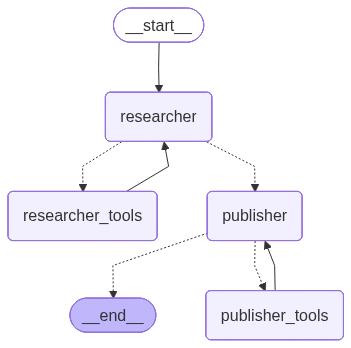

In [42]:
# 그래프 시각화
display(Image(enterprise_app.get_graph().draw_mermaid_png()))

In [46]:
run_enterprise_team()

[멀티 에이전트 자동화 시스템 가동]
대화를 종료하려면 '종료'를 입력하세요
2026년 AI에이전트 트렌드를 조사하고, 우리 회사 기술평가 업무에 어떻게 쓰일지 정리해서 노션에 올리고 텍스트 파일로 저장한 뒤, 슬랙에 쏴줘.

 --- 멀티 에이전트 팀 작업 현황 ---
[리서치] 자료 수집 중 -> 도구(tavily_search_results_json) 가동
[리서치] 자료 수집 중 -> 도구(search_internal_docs) 가동
 (리서처 도구) 데이터 확보! [[{"title": "What's next in AI: 7 trends ...]
 (리서처 도구) 데이터 확보! [페이지 5 / 6    및 제시    ③ 기타 가치평가  기타 기술가치평...]
[리서처] 자료 수집 완! -> [퍼블리셔 부서로 이관]
[퍼블리셔] 배포 작업 시작 -> 도구(create_notion_page) 가동
[퍼블리셔] 배포 작업 시작 -> 도구(save_to_file) 가동
[퍼블리셔] 배포 작업 시작 -> 도구(send_slack_message) 가동
 (퍼블리셔 도구) 작업 완료! [Notion 페이지 '2026년 AI 에이전트 트렌드 및 기술평가 업무 ...]
 (퍼블리셔 도구) 작업 완료! [파일 '2026_AI_Agent_Trends.txt'이 성공적으로 저장되...]
 (퍼블리셔 도구) 작업 완료! [Slack 메시지가 성공적으로 전송되었습니다....]
[퍼블리셔] 최종 보고서:
요청하신 자료의 리서치부터 노션 저장, 슬랙 보고까지 완벽히 처리했습니다.

종료
대화를 종료합니다. 다음에 또 이용해주세요!


### **7. Human-in-the-Loop(HITL) 사용법**
- 지금까지의 에이전트는 한 번 명령을 내리면 끝까지 알아서 실행하는 형태였는데, 현업에서 중요한 업무를 사람의 확인없이 실행해버리면 대형 사고가 발생. (ex DB삭제, 고객전체 메일 발송, 자동결제 등)
- 사람이 통제할 수 있도록 그래프가 특정 노드로 진입하기 직전에 프로세스를 **일시정지** 시키고, 사람의 승인을 기다리게 만들기

In [5]:
from langchain_core.messages import ToolMessage

In [ ]:
# 상태 정의
class HitlState(TypedDict) :
    messages: Annotated[list, add_messages]

# 실습용 슬랙 툴
@tool
def send_slack_message_mock(message: str) -> str :
    """슬랙(Slack)으로 메시지를 전송하는 도구입니다."""

    client = WebClient(token=SLACK_BOT_TOKEN)

    try:
        # chat_postMessage : Slack 채널에 메시지 게시
        response = client.chat_postMessage(
            channel=SLACK_CHANNEL_ID,   # 슬랙 채널 ID
            text=message
        )
        return f"Slack 메시지가 성공적으로 전송되었습니다. {message}"
    
    except Exception as e :
        return f"Slack 메시지 전송 실패: {e}"
    
    print(f"슬랙 메시지 발송 완료: {message}")
    return "슬랙 전송 완!"

tools = [send_slack_message_mock]

llm = ChatOpenAI(model='gpt-4o', temperature=0.1)
llm_with_tools = llm.bind_tools(tools)


def agent_node(state:HitlState) :
    response = llm_with_tools.invoke(state["messages"])
    return {'messages':[response]}

graph = StateGraph(HitlState)
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")

# HTIL에서는 절대 빠지면 안 되는 부분! 사람의 승인을 받을 때 작업을 잠시 멈추는 동안 대화내역 뿐만 아니라
# 이전 작업 내용(state)을 기억하고 있어야 하기 때문에 필수!!!
memory = MemorySaver()
hitl_app = graph.compile(checkpointer=memory, interrupt_before=['tools'])  # tools 노드 넘어가기 직전에 작업 멈춰!


# 실행 함수
def run_hitl_agent() :
    config = {'configurable': {'thread_id':'customer_1'}}

    print('[⛑️ 안전 제일 에이전트 시스템 가동]')
    print("대화를 종료하려면 '종료'를 입력하세요")
    print('='*50)

    while True:
        user_input = input('사용자\t:')
        print(user_input)

        if user_input.strip()== '종료':
            print('대화를 종료합니다. 다음에 또 이용해주세요!')
            break
        if not user_input.strip():
            continue

        print("\n --- 에이전트 판단 ---")

        for event in hitl_app.stream(
            {"messages": [("user", user_input)]},
            config,
            stream_mode="updates"
        ):
            
            for node_name, state_update in event.items() :
                if node_name == "agent" :
                    message = state_update["messages"][-1]
                    if message.tool_calls :
                        print(f"[에이전트] 실행 -> 도구({message.tool_calls[0]['name']}) 가동")
                    else :
                        print(f"[답변]: {message.content}")

        # 그래프에서 작업이 멈춘 상태 확인
        snapshot = hitl_app.get_state(config)
        # next: 다음에 실행될 노드 (반환값은 튜플)
        next_step = snapshot.next

        #### 3. 저장된 데이터 확인하기
        print("현재 어느 단계인가요? :", snapshot.next)  # 다음에 실행될 노드 이름
        print("지금까지 쌓인 메시지들 :", snapshot.values["messages"]) # 대화 기록 전체

        # next_step에 값이 있고, 첫 내용에 tools가 있다면
        # (도구 사용없이 그냥 답변만 하고 끝나면 next_step에는 빈 튜플이 반환되니까
        # next_step[0]만으로는 에러가 발생할 수 있어서 조건을 더 넣어줌)
        if next_step and next_step[0] == 'tools':     # 다음 할 일이 tools라면, 사용자에게 물어보기
            print("\n⚠️[시스템 경고] 에이전트가 외부로 메시지를 발송하려고 합니다!")

            # 사람 개입
            approval = input('정말로 실행하시겠습니까? (승인은 "y", 거절은 "n")')

            if approval.lower() == 'y':
                print("\n✅[승인 완료] 작업을 재개합니다...")

                # 승인 후 작업 재개시, 새로운 메시지 대신 None을 입력
                # (아무값도 주지 않고 다시 stream 호출하면, 아까 멈췄던 곳부터 다시 달림!)
                for event in hitl_app.stream(None, config, stream_mode="updates") :
                    for node_name, state_update in event.items() :
                        if node_name == 'tools' :
                            print('[도구 노드 실행 완료]')
                        elif node_name == 'agent' :
                            print(f"[최종 답변]: {state_update["messages"][-1].content}")
            else:
                print("🚫[승인 거절] 작업을 취소합니다.")
                # 거절했을 때는 승인했을 때와 달리, 반환되는 객체가 ToolMessage가 아니라서 에러가 나는데,
                # 이를 방지하기 위해 도구 객체로 거절 메시지를 만들어서 LLM에 전달
                # ※ 에러 이유: 에이전트의 마지막 기억 상태가 도구를 쓴다인데, 그에 대한 답이 ToolMessage객체가 아니라서
                # (실무에서는 여기서 상태를 이전으로 돌리거나 취소 메시지를 넣는 추가 작업을 합니다)

                # 멈춰있는 시점에서 가장 마지막으로 남겨진 대화 기록
                last_message = snapshot.values["messages"][-1]
                # 사용할 도구가 1개밖에 없으므로 인덱싱으로 가져오기
                tool_call = last_message.tool_calls[0]

                # ToolMessage 객체에 거절 메시지 등록
                reject_msg = ToolMessage(
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"],
                    content="관리자가 실행을 승인하지 않아 작업이 취소되었습니다."
                )

                # update_state: 상태(state)에 업데이트
                hitl_app.update_state(
                    config,
                    {"messages": [reject_msg]},   # 업데이트 할 변수 및 내용
                    as_node="tools"              # 업데이트 할 노드 (해당 노드의 실행결과)
                )

                # 상태 업데이트 후, 에이전트가 취소에 대한 대답을 출력
                for event in hitl_app.stream(None, config, stream_mode="updates") :
                    for node_name, state_update in event.items() :
                        if node_name == 'agent' :
                            print(f"[최종 답변]: {state_update['messages'][-1].content}")
        
        print("\n=================================================")


In [13]:
run_hitl_agent()

[⛑️ 안전 제일 에이전트 시스템 가동]
대화를 종료하려면 '종료'를 입력하세요
슬랙에 하이 라고 보내줘

 --- 에이전트 판단 ---
[에이전트] 실행 -> 도구(send_slack_message_mock) 가동
현재 어느 단계인가요? : ('tools',)
지금까지 쌓인 메시지들 : [HumanMessage(content='슬랙에 하이 라고 보내줘', additional_kwargs={}, response_metadata={}, id='814a9448-aa79-4f0b-88f0-a551a25f3f6a'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 64, 'total_tokens': 82, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a7c3cc1f7d', 'id': 'chatcmpl-DSBthEz6BjNexUuzcpgrpQff5MBaB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6aae-10a0-7f90-864d-69b59c702264-0', tool_calls=[{'name': 'send_slack_message_mock', 'args': {'message